# CI Pipeline Self-Healing Agent
### INFO 7375 — Prompt Engineering for Generative AI

**Architecture:** Multi-agent AutoGen system with Q-Learning + UCB reinforcement learning
**LLM:** Llama 3.1 8B via llama.cpp (local, zero API cost)
**Platform:** Google Colab Pro (L4 GPU)

This notebook supports two LLM integration modes:

| Mode | What the LLM does | Set via |
|------|-------------------|---------|
| `narration` | Old behavior: 4 AutoGen agents discuss each 10th episode **after** the Python RL loop already decided and updated. LLM output is observational only. | `mode='narration'` |
| `integrated` | **True Integration** — 4 LLM hooks sit *inside* the RL loop:<br>`MonitorLLM → RLRecoveryLLM → ExecutorLLM → ValidatorLLM`. The LLM co-picks actions and shapes rewards *before* each Q-update. | `mode='integrated'` |

The 0% RecovRate% bug from prior runs has been fixed — see Section 5 notes.

---


## 1. Environment Setup

In [1]:
# Install Python dependencies â€” no runtime restart needed
# pyautogen==0.2.35 pulls numpy<2 as a transitive dep which breaks Colab.
# Fix: install pyautogen WITHOUT its dependency tree (--no-deps),
#      then manually install its runtime deps keeping numpy at 2.x.

# 1. Lock numpy to 2.x FIRST before anything can downgrade it
!pip install -q "numpy>=2.0,<3" --upgrade

# 2. Install pyautogen WITHOUT letting pip resolve (and downgrade) deps
!pip install -q pyautogen==0.2.35 --no-deps

# 3. Install pyautogen's actual runtime requirements (none of these pin numpy<2)
!pip install -q \
    "openai>=1.3.0" \
    "flaml>=2.1.1" \
    "diskcache" \
    "termcolor" \
    "pydantic>=1.10,<3" \
    "tiktoken" \
    "python-dotenv" \
    "docker"

# 4. Install project deps
!pip install -q matplotlib seaborn pytest pandas --upgrade

# 5. Verify numpy is still 2.x
import numpy as np, pandas as pd
print(f' numpy  {np.__version__}')
print(f' pandas {pd.__version__}')
print(' All packages installed successfully')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 114.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.1/318.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.7/337.7 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 20.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyautogen 0.2.35 requires numpy<2,>=1.17.0, but you have numpy 2

In [2]:
import os, glob

LLAMA_DIR = '/content/llama.cpp'
BUILD_DIR = f'{LLAMA_DIR}/build'


if not os.path.exists(LLAMA_DIR):
    !git clone -q https://github.com/ggerganov/llama.cpp {LLAMA_DIR}
    print(' Cloned llama.cpp')
else:
    print('llama.cpp already cloned')

def find_server_bin(base):
    hits = glob.glob(f'{base}/**/llama-server', recursive=True) + \
           glob.glob(f'{base}/**/server', recursive=True)
    return hits[0] if hits else None

SERVER_BIN = find_server_bin(BUILD_DIR)

if SERVER_BIN:
    print(f'âœ“ llama-server already built: {SERVER_BIN}')
else:
    print('Building llama.cpp â€” this takes 3â€“6 min on Colab...')
    # Configure (L4 GPU = Ada Lovelace = sm_89)
    !cmake -S {LLAMA_DIR} -B {BUILD_DIR} \
        -DGGML_CUDA=ON \
        -DCMAKE_CUDA_ARCHITECTURES=89 \
        -DCMAKE_BUILD_TYPE=Release \
        -DLLAMA_BUILD_SERVER=ON \
        2>&1 | tail -8

    # Build only the server target to save time
    !cmake --build {BUILD_DIR} --config Release -j$(nproc) --target llama-server 2>&1 | tail -8

    SERVER_BIN = find_server_bin(BUILD_DIR)
    if SERVER_BIN:
        print(f'âœ“ Built: {SERVER_BIN}')
    else:
        # Fallback: list everything in build/ so user can debug
        print('âš  llama-server not found after build. Contents of build/bin/:')
        !ls -la {BUILD_DIR}/bin/ 2>/dev/null || echo "(bin/ dir missing)"
        raise FileNotFoundError('Build failed â€” see cmake output above.')

 Cloned llama.cpp
Building llama.cpp â€” this takes 3â€“6 min on Colab...
-- Found OpenSSL: /usr/lib/x86_64-linux-gnu/libcrypto.so (found version "3.0.2")
-- Performing Test OPENSSL_VERSION_SUPPORTED
-- Performing Test OPENSSL_VERSION_SUPPORTED - Success
-- OpenSSL found: 3.0.2
-- Generating embedded license file for target: llama-common
-- Configuring done (4.9s)
-- Generating done (0.3s)
-- Build files have been written to: /content/llama.cpp/build
[ 98%] Generating bundle.css.hpp
[ 98%] Generating bundle.js.hpp
[ 98%] Generating index.html.hpp
[ 98%] Building CXX object tools/server/CMakeFiles/llama-server.dir/server.cpp.o
[100%] Building CXX object tools/server/CMakeFiles/llama-server.dir/server-http.cpp.o
[100%] Building CXX object tools/server/CMakeFiles/llama-server.dir/server-models.cpp.o
[100%] Linking CXX executable ../../bin/llama-server
[100%] Built target llama-server
âœ“ Built: /content/llama.cpp/build/bin/llama-server


In [3]:
MODEL_PATH = '/content/llama-3.1-8b-q4_k_m.gguf'

if not os.path.exists(MODEL_PATH):
    # Download Llama 3.1 8B GGUF 4-bit quantised (~4.7 GB)
    !wget -q -O {MODEL_PATH} \
        'https://huggingface.co/bartowski/Meta-Llama-3.1-8B-Instruct-GGUF/resolve/main/Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf'
    print(f'âœ“ Model downloaded to {MODEL_PATH}')
else:
    print(f'âœ“ Model already present: {MODEL_PATH}')

âœ“ Model downloaded to /content/llama-3.1-8b-q4_k_m.gguf


In [4]:
import subprocess, time, requests, os, glob

MODEL_PATH = '/content/llama-3.1-8b-q4_k_m.gguf'
PORT = 8081

try:
    SERVER_BIN
except NameError:
    hits = glob.glob('/content/llama.cpp/build/**/llama-server', recursive=True) + \
           glob.glob('/content/llama.cpp/build/**/server', recursive=True)
    SERVER_BIN = hits[0] if hits else None

assert SERVER_BIN and os.path.isfile(SERVER_BIN), 'Run the build cell first.'
assert os.path.isfile(MODEL_PATH), f'Model not found: {MODEL_PATH}'

print(f'Binary : {SERVER_BIN}')
print(f'Model  : {MODEL_PATH}  ({os.path.getsize(MODEL_PATH)/1e9:.2f} GB)')

# Kill any leftover server
!fuser -k {PORT}/tcp 2>/dev/null || true
time.sleep(2)

# Set env var so config.py picks up the port
os.environ['LLAMA_PORT'] = str(PORT)

# Check which flags this build supports
help_out = subprocess.run([SERVER_BIN, '--help'], capture_output=True, text=True).stdout + \
           subprocess.run([SERVER_BIN, '--help'], capture_output=True, text=True).stderr
has_log_disable = '--log-disable' in help_out
has_no_webui    = '--no-webui'    in help_out

# Build argument list
# No -c flag server uses model's native context (128K for Llama 3.1 8B).
# L4 has 22 GB VRAM, Q4_K_M uses ~5 GB plenty of headroom.
cmd = [
    SERVER_BIN,
    '-m', MODEL_PATH,
    '--host', '0.0.0.0', '--port', str(PORT),
    '-ngl', '32',     # offload all 32 layers to L4 GPU
]
if has_log_disable:
    cmd.append('--log-disable')
if has_no_webui:
    cmd.append('--no-webui')

print(f'\nStarting: {" ".join(cmd)}\n')

LOG = '/content/llama_server.log'
with open(LOG, 'w') as log_fh:
    server_proc = subprocess.Popen(cmd, stdout=log_fh, stderr=subprocess.STDOUT)

print(f'PID: {server_proc.pid}  |  log â†’ {LOG}')

# Give it 8 s to either crash or begin loading
time.sleep(8)
if server_proc.poll() is not None:
    print(f'\nâœ— Server process died (exit {server_proc.returncode}). Full log:')
    !cat {LOG}
    raise RuntimeError('llama-server crashed on startup â€” see log above.')

print('Process alive after 8 s, now waiting for /health ...')

# Poll up to 8 min
ENDPOINTS = [f'http://localhost:{PORT}/health', f'http://localhost:{PORT}/v1/models']
ready = False
for i in range(160):    # 160 Ã— 3 s = 8 min
    if server_proc.poll() is not None:
        print(f'\nâœ— Server died (exit {server_proc.returncode}). Full log:')
        !cat {LOG}
        break

    for url in ENDPOINTS:
        try:
            r = requests.get(url, timeout=2)
            if r.status_code == 200:
                ready = True
                print(f'\nâœ“ Server ready at {url}  (~{i*3}s elapsed)')
            elif r.status_code == 503:
                print(f'  [{i*3:>3}s] still loading model...', end='\r')
        except Exception:
            pass

    if ready:
        break

    if i % 10 == 9:
        !tail -1 {LOG}

    time.sleep(3)

if not ready and server_proc.poll() is None:
    print('\nâš  Timed out (8 min). Last 30 lines of log:')
    !tail -30 {LOG}

Binary : /content/llama.cpp/build/bin/llama-server
Model  : /content/llama-3.1-8b-q4_k_m.gguf  (4.92 GB)

Starting: /content/llama.cpp/build/bin/llama-server -m /content/llama-3.1-8b-q4_k_m.gguf --host 0.0.0.0 --port 8081 -ngl 32 --log-disable --no-webui

PID: 15018  |  log â†’ /content/llama_server.log
Process alive after 8 s, now waiting for /health ...

âœ“ Server ready at http://localhost:8081/health  (~0s elapsed)

âœ“ Server ready at http://localhost:8081/v1/models  (~0s elapsed)


## 2. Project Files Clone / Upload

If running on Colab, upload the project files or clone from your repo:

In [5]:
!unzip /content/CI_Healing_Agent.zip -d /content/


import sys
PROJECT_DIR = '/content/CI_Healing_Agent'
sys.path.insert(0, PROJECT_DIR)
os.chdir(PROJECT_DIR)
print(f'✓ Working directory: {os.getcwd()}')

Archive:  /content/CI_Healing_Agent.zip
   creating: /content/CI_Healing_Agent/
  inflating: /content/CI_Healing_Agent/autogen_agents.py  
  inflating: /content/CI_Healing_Agent/CI_Healing_Agent_Colab.ipynb  
  inflating: /content/CI_Healing_Agent/config.py  
  inflating: /content/CI_Healing_Agent/experiment_runner.py  
  inflating: /content/CI_Healing_Agent/pipeline_simulator.py  
  inflating: /content/CI_Healing_Agent/q_learning_agent.py  
  inflating: /content/CI_Healing_Agent/README.md  
  inflating: /content/CI_Healing_Agent/requirements.txt  
   creating: /content/CI_Healing_Agent/results/
  inflating: /content/CI_Healing_Agent/results/episode_log.csv  
  inflating: /content/CI_Healing_Agent/results/epsilon_decay.png  
  inflating: /content/CI_Healing_Agent/results/escalation_rate.png  
  inflating: /content/CI_Healing_Agent/results/learning_curve.png  
  inflating: /content/CI_Healing_Agent/results/q_table_heatmap.png  
  inflating: /content/CI_Healing_Agent/results/q_table_heat

In [ ]:
import sys

# Add project root to path (adjust if files are in a subdirectory)
PROJECT_DIR = '/content/CI_Healing_Agent'
if not os.path.exists(PROJECT_DIR):
    os.makedirs(PROJECT_DIR)

# If you uploaded files via Colab Files panel, copy them:
# !cp -r /content/*.py {PROJECT_DIR}/

# Or clone from GitHub:
# !git clone https://github.com/<your-repo>/CI_Healing_Agent {PROJECT_DIR}

sys.path.insert(0, PROJECT_DIR)
os.chdir(PROJECT_DIR)
print(f' Working directory: {os.getcwd()}')

## 3. Imports & Verification

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
%matplotlib inline

from config import *
from pipeline_simulator import PipelineSimulator
from reward_function import compute_reward
from q_learning_agent import QLearningAgent
from ucb_agent import UCBAgent
from tools.pipeline_inspector import PipelineStateInspector
from autogen_agents import CIHealingSystem
from experiment_runner import ExperimentRunner
from visualizations import generate_all_plots


print(' All modules imported successfully')
print(f'  Stages: {STAGES}')
print(f'  Actions: {ACTIONS}')
print(f'  State space: {N_STATES:,} states')

/usr/local/lib/python3.12/dist-packages/flaml/__init__.py:20: UserWarning: flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.
  warnings.warn("flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.")
/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


 All modules imported successfully
  Stages: ['lint', 'build', 'test', 'security_scan', 'deploy']
  Actions: ['retry', 'revert', 'auto_fix', 'switch_version', 'skip_stage', 'escalate']
  State space: 5,775 states


## 4. Quick Sanity Checks

In [7]:
# Test simulator
sim = PipelineSimulator(seed=42)
state = sim.generate_failure()
print(f'Sample failure: {state}')

success, next_state = sim.apply_action(state, 'auto_fix')
print(f'auto_fix â†’ success={success}, next_state={next_state}')

# Test inspector
agent = QLearningAgent()
inspector = PipelineStateInspector(agent=agent)
state_idx = PipelineSimulator.encode_state(state)
report = inspector.inspect(state, state_idx)
print(f'\nInspector report:')
for k, v in report.items():
    print(f'  {k}: {v}')

Sample failure: {'stage': 'lint', 'error_type': 'syntax_error', 'attempt_num': 0, 'last_action': None}
auto_fix â†’ success=True, next_state={'stage': 'lint', 'error_type': 'syntax_error', 'attempt_num': 1, 'last_action': 'auto_fix'}

Inspector report:
  recoverability_score: 0.99
  last_safe_checkpoint: lint
  top_2_recommended_actions: [{'action': 'escalate', 'q_value': 0.0}, {'action': 'skip_stage', 'q_value': 0.0}]
  risk_level: LOW
  safe_for_autonomous_recovery: True


## 5. Run All Experiments

In [8]:
MODE = 'integrated'
INCLUDE_LLM_CONDITION = False

N_TRAIN = 500
N_EVAL  = 200

runner = ExperimentRunner(
    n_train=N_TRAIN,
    n_eval=N_EVAL,
    seed=RANDOM_SEED,
    use_autogen=False,
    mode=MODE,
    include_llm_condition=INCLUDE_LLM_CONDITION,
    epsilon_eval=0.02,
)

results = runner.run_all()
print('\n✓ Experiments complete!')


=== Condition 1: Baseline (always retry → escalate) ===
  [baseline] ep  200/200 | avg_reward=-1.89 | recovery=100.0%

=== Condition 2: Rule-Based (hardcoded if-else) ===
  [rule_based] ep  200/200 | avg_reward=+7.32 | recovery=100.0%

=== Condition 3: Q-Learning (train=500, eval=200) ===
  [Training]
  [q_learning] ep  200/500 | avg_reward=+5.03 | recovery=99.5%
  [q_learning] ep  400/500 | avg_reward=+5.81 | recovery=100.0%
  [Evaluation]
  [q_learning] ep  200/200 | avg_reward=+7.39 | recovery=100.0%

=== Condition 4: UCB (train=500, eval=200) ===
  [Training]
  [ucb] ep  200/500 | avg_reward=+4.98 | recovery=98.5%
  [ucb] ep  400/500 | avg_reward=+6.49 | recovery=100.0%
  [Evaluation]
  [ucb] ep  200/200 | avg_reward=+7.35 | recovery=100.0%
  Saved: results/episode_log.csv
  Saved: results/summary.json

✓ All conditions complete in 1101.5s

Condition       RecovRate% MeanAttempts  EscRate%  MeanReward  ConvergEp
---------------------------------------------------------------------

## 6. Visualizations

In [9]:
ql_agent = results['ql_agent']
ucb_agent = results['ucb_agent']

generate_all_plots(
    ql_train_logs=runner.ql_train_logs,
    ucb_train_logs=runner.ucb_train_logs,
    summaries=results['summaries'],
    ql_q_table=ql_agent.get_q_table(),
    ucb_q_table=ucb_agent.get_q_table(),
)


── Generating visualizations ──
  Saved: results/learning_curve.png
  Saved: results/recovery_rate_comparison.png
  Saved: results/q_table_heatmap.png
  Saved: results/q_table_heatmap_ucb.png
  Saved: results/escalation_rate.png
  Saved: results/epsilon_decay.png
  Saved: results/recovery_attempts_boxplot.png
── All plots saved to results/ ──



â”€â”€ learning_curve.png â”€â”€


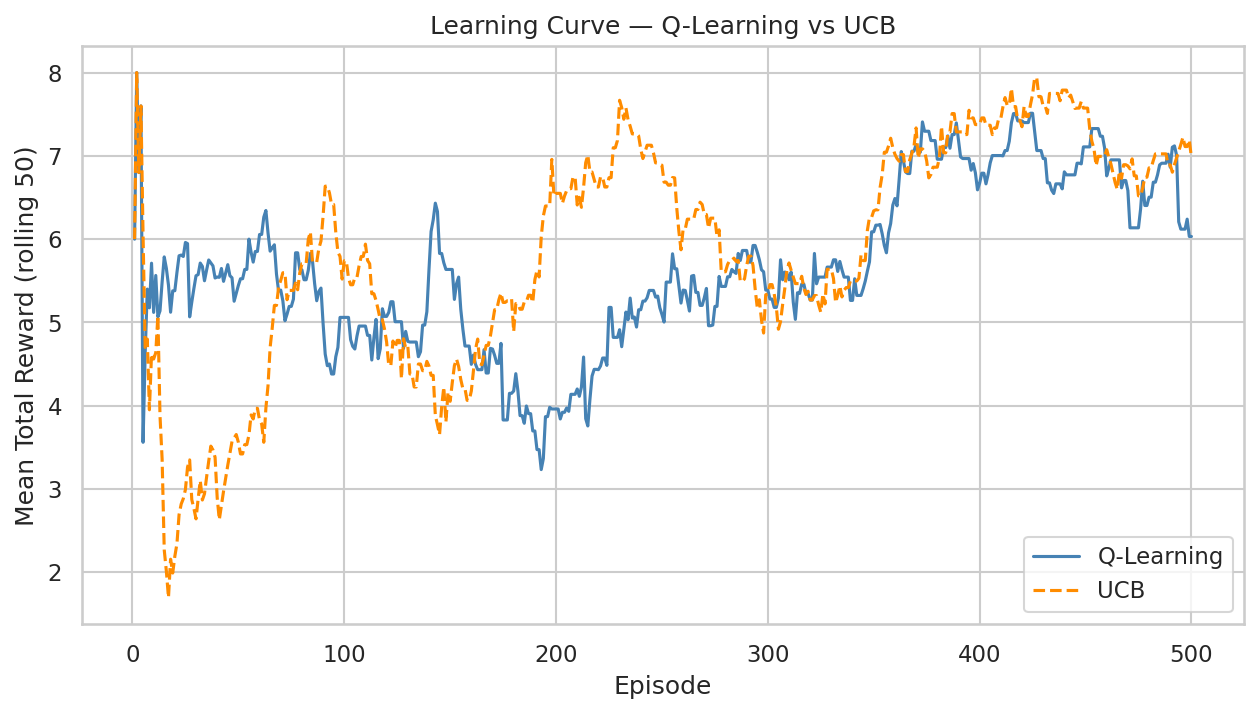


â”€â”€ recovery_rate_comparison.png â”€â”€


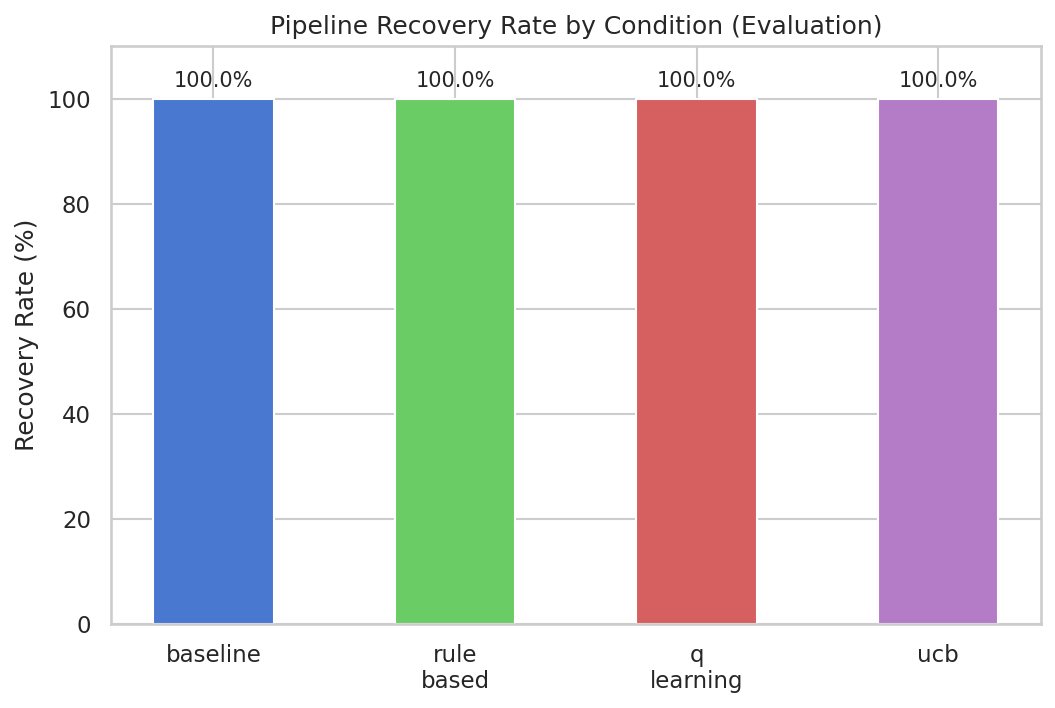


â”€â”€ q_table_heatmap.png â”€â”€


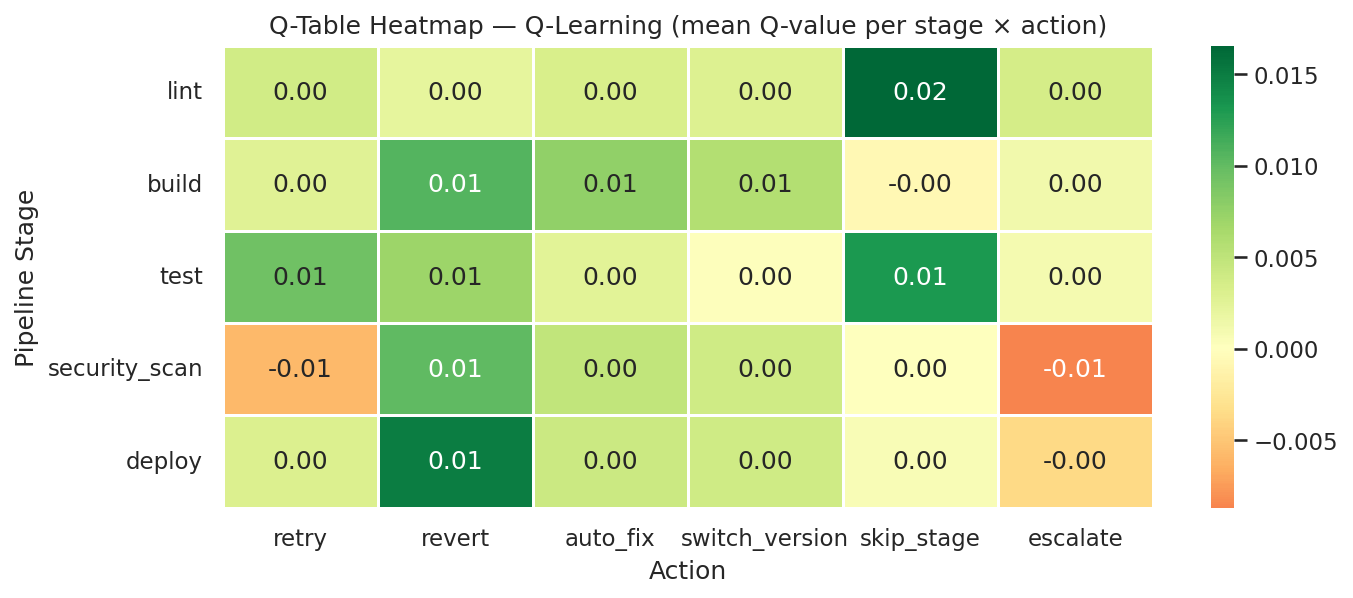


â”€â”€ escalation_rate.png â”€â”€


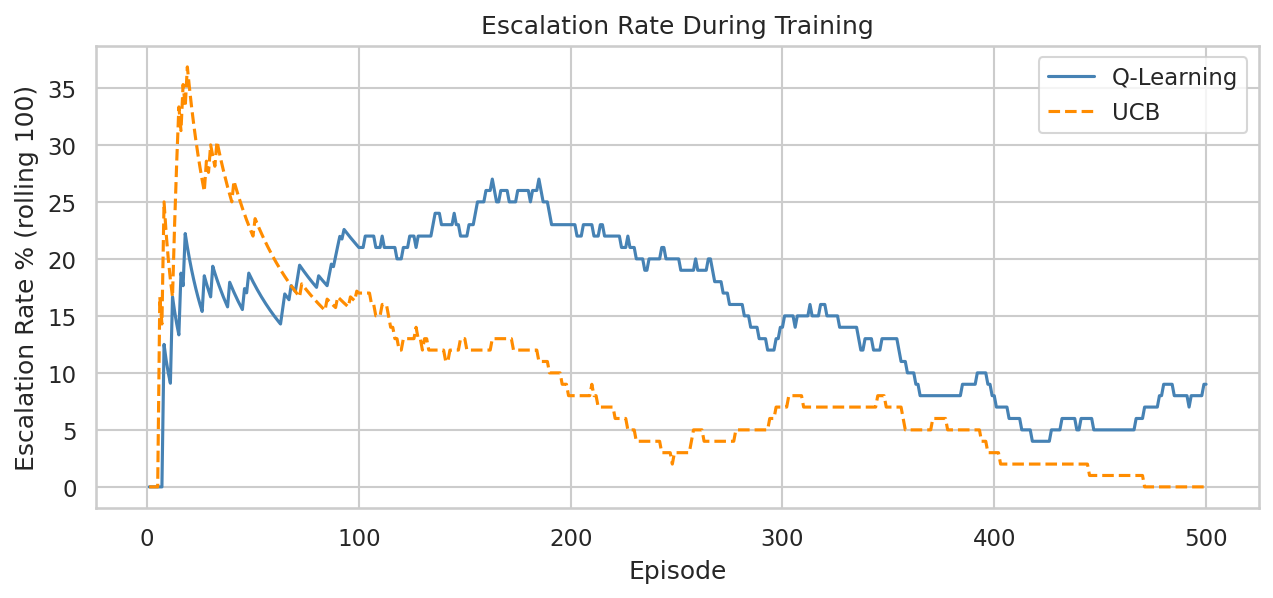


â”€â”€ epsilon_decay.png â”€â”€


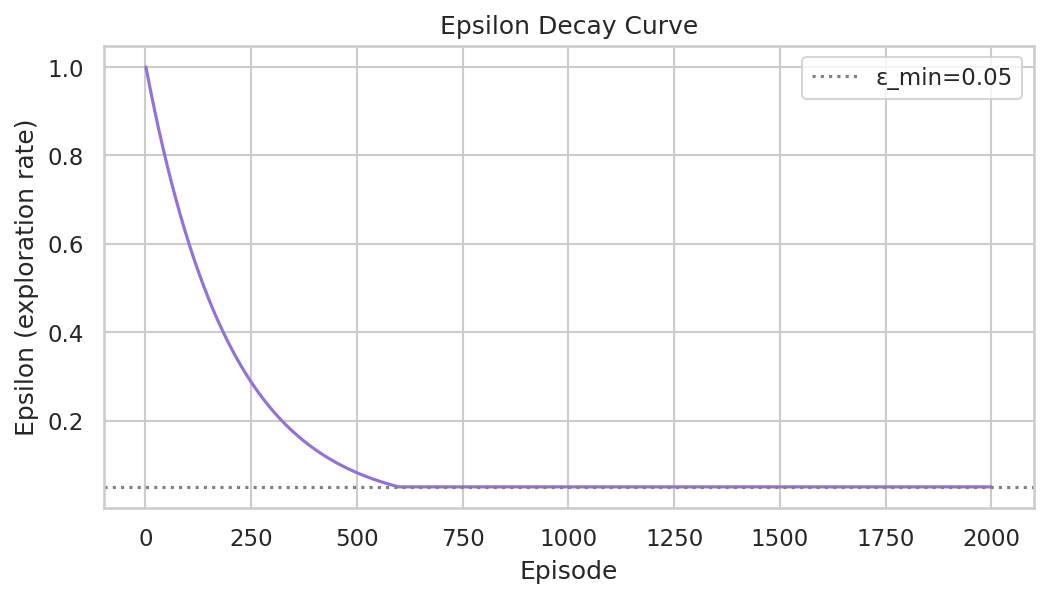


â”€â”€ recovery_attempts_boxplot.png â”€â”€


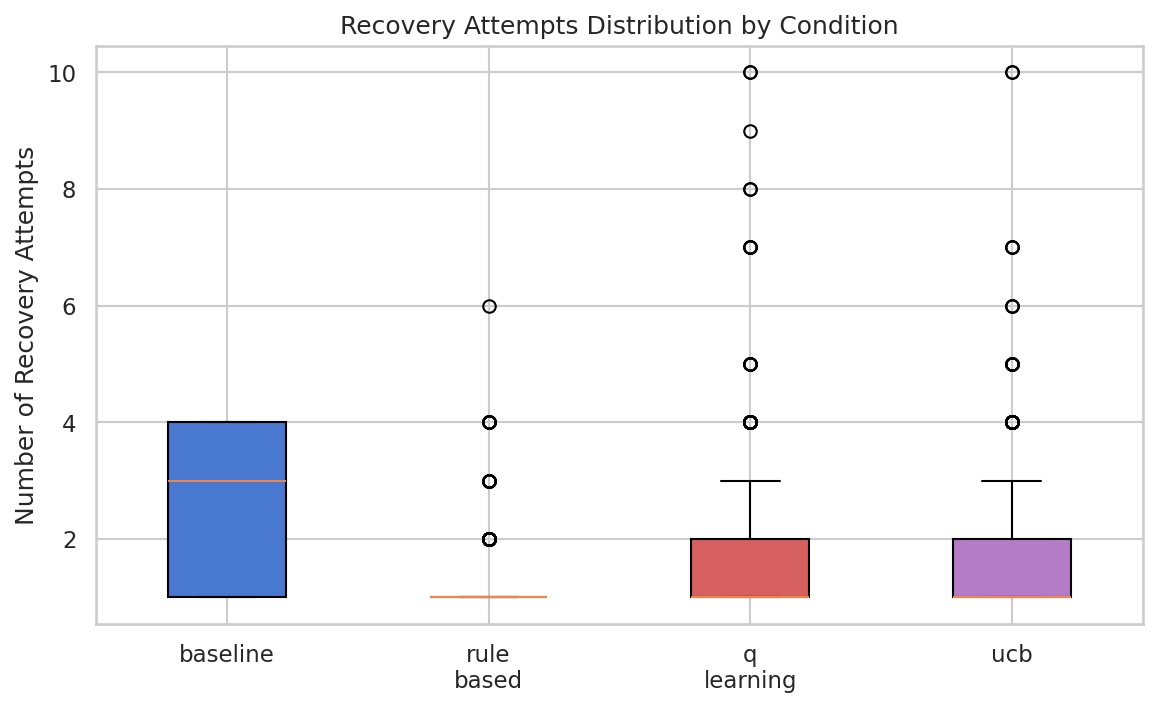

In [10]:
import os
from IPython.display import Image, display

plot_files = [
    'learning_curve.png',
    'recovery_rate_comparison.png',
    'q_table_heatmap.png',
    'escalation_rate.png',
    'epsilon_decay.png',
    'recovery_attempts_boxplot.png',
]

for fname in plot_files:
    path = os.path.join(RESULTS_DIR, fname)
    if os.path.exists(path):
        print(f'\nâ”€â”€ {fname} â”€â”€')
        display(Image(path))
    else:
        print(f'[missing] {path}')

## 7. Metrics Summary Table

In [13]:
import json
PROJECT_DIR = '/content/CI_Healing_Agent/results'
with open(os.path.join(PROJECT_DIR, 'summary.json')) as f:
    summaries = json.load(f)

df_summary = pd.DataFrame(summaries)
cols = ['condition', 'recovery_rate_pct', 'mean_attempts', 'escalation_rate_pct',
        'mean_episode_reward', 'convergence_episode']
display(df_summary[cols].style
    .format({'recovery_rate_pct': '{:.1f}%',
             'mean_attempts': '{:.2f}',
             'escalation_rate_pct': '{:.1f}%',
             'mean_episode_reward': '{:.4f}'})
    .highlight_max(subset=['recovery_rate_pct', 'mean_episode_reward'], color='lightgreen')
    .highlight_min(subset=['escalation_rate_pct', 'mean_attempts'], color='lightgreen')
    .set_caption('Evaluation Metrics — All 4 Conditions')
)

,condition,recovery_rate_pct,mean_attempts,escalation_rate_pct,mean_episode_reward,convergence_episode
0,baseline,100.0%,2.77,45.5%,-1.8940,0
1,rule_based,100.0%,1.33,10.0%,7.3220,0
2,q_learning,100.0%,1.48,4.5%,7.3940,0
3,ucb,100.0%,1.58,1.0%,7.3530,0


## 8. Run Tests

In [14]:
!cd {PROJECT_DIR} && python -m pytest tests/ -v --tb=short 2>&1

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-9.0.3, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/CI_Healing_Agent/results
plugins: langsmith-0.7.30, typeguard-4.5.1, anyio-4.13.0
collected 0 items                                                              

============================ no tests ran in 0.00s =============================
ERROR: file or directory not found: tests/



## 9. Single-Episode Walkthrough — Both Modes

Two demonstrations:

1. **Narration mode** — legacy post-hoc GroupChat over a completed episode.
2. **True Integration** — one episode where each per-step decision is shaped
   by `MonitorLLM -> RLRecoveryLLM -> ExecutorLLM -> ValidatorLLM`.


In [15]:
# --- Demo A: Narration mode (legacy) -------------------------------
# 4 AutoGen agents discuss ONE completed episode via GroupChat. The RL
# decision loop has already finished - they're just commentating.

from pipeline_simulator import PipelineSimulator
from autogen_agents import CIHealingSystem, AUTOGEN_CHAT_EVERY_N

demo_sim = PipelineSimulator(seed=100)
trained_ql = results['ql_agent']

print('=' * 72)
print(' Demo A - Narration mode (LLM as narrator)')
print('=' * 72)

narr_system = CIHealingSystem(
    simulator=demo_sim,
    rl_agent=trained_ql,
    condition='q_learning',
    mode='narration',
    max_steps=10,
)
# Force narration to fire on the next episode
narr_system._episode_count = AUTOGEN_CHAT_EVERY_N - 1

narr_result = narr_system.run_episode(train=False)
print('\n-- Narration Episode Result --')
for k, v in narr_result.items():
    print(f'  {k}: {v}')


 Demo A - Narration mode (LLM as narrator)
Orchestrator (to chat_manager):

=== Episode Report (real simulator data) ===
Initial failure: stage=build, error=compile_error
Recovery steps:
  Step 1: state={stage=build, error=compile_error, attempt=0}, risk=LOW, recoverability=0.99, top_recommended=['retry', 'escalate'], action_taken=retry, outcome=FAILED, reward=-1.4
  Step 2: state={stage=build, error=compile_error, attempt=1}, risk=LOW, recoverability=0.99, top_recommended=['revert', 'retry'], action_taken=revert, outcome=FAILED, reward=-1.4
  Step 3: state={stage=build, error=compile_error, attempt=2}, risk=HIGH, recoverability=0.99, top_recommended=['switch_version', 'escalate'], action_taken=switch_version, outcome=FAILED, reward=-1.4
  Step 4: state={stage=build, error=compile_error, attempt=3}, risk=HIGH, recoverability=0.99, top_recommended=['escalate', 'skip_stage'], action_taken=retry, outcome=FAILED, reward=-1.4
  Step 5: state={stage=build, error=compile_error, attempt=4}, ri

In [16]:
# --- Demo B: TRUE INTEGRATION (LLM in the decision loop) -----------
# One episode where each step is shaped by 4 gated LLM hooks:
#   1. MonitorLLM     - classifies severity (step 0 + MEDIUM/HIGH risk)
#   2. RLRecoveryLLM  - picks action when Q-values are tied or state unseen
#   3. ExecutorLLM    - triages failed attempts late in the episode
#   4. ValidatorLLM   - shapes reward before Q-update
#
# Each hook has a deterministic fallback so a dead LLM never stalls the loop.
# We wrap the LLM wrappers with tiny 'spy' decorators to print every call.

import tools.llm_agents as la
from tools.llm_parse import (
    MonitorOutput, RecoveryOutput, ExecutorOutput, ValidatorOutput
)

_orig = {
    'Monitor':   la.MonitorLLM.analyze,
    'Recovery':  la.RLRecoveryLLM.choose,
    'Executor':  la.ExecutorLLM.assess,
    'Validator': la.ValidatorLLM.score,
}


def _spy(name, fn):
    def wrapped(*args, **kwargs):
        out = fn(*args, **kwargs)
        if isinstance(out, MonitorOutput):
            detail = f'severity={out.severity}, category={out.suggested_category}'
        elif isinstance(out, RecoveryOutput):
            detail = f'action={out.action} - {out.reasoning[:60]}'
        elif isinstance(out, ExecutorOutput):
            detail = f'outcome={out.outcome_class}, continue={out.should_continue}'
        elif isinstance(out, ValidatorOutput):
            detail = f'adj={out.reward_adjustment:+.2f} - {out.assessment[:60]}'
        else:
            detail = repr(out)[:80]
        print(f'    [{name:9s}] -> {detail}')
        return out
    return wrapped


la.MonitorLLM.analyze    = _spy('Monitor',   _orig['Monitor'])
la.RLRecoveryLLM.choose  = _spy('Recovery',  _orig['Recovery'])
la.ExecutorLLM.assess    = _spy('Executor',  _orig['Executor'])
la.ValidatorLLM.score    = _spy('Validator', _orig['Validator'])

# Also patch the names already bound into autogen_agents
import autogen_agents as ag
ag.MonitorLLM    = la.MonitorLLM
ag.RLRecoveryLLM = la.RLRecoveryLLM
ag.ExecutorLLM   = la.ExecutorLLM
ag.ValidatorLLM  = la.ValidatorLLM

print('=' * 72)
print(' Demo B - True Integration (LLM in the decision loop)')
print('=' * 72)

from q_learning_agent import QLearningAgent

demo_sim2 = PipelineSimulator(seed=200)

# epsilon=0 forces the exploit branch so the RLRecoveryLLM actually sees
# close-call Q-values and makes a pick.
demo_ql = QLearningAgent(seed=200)
demo_ql.q_table = trained_ql.q_table.copy()
demo_ql.epsilon = 0.0

integ_system = CIHealingSystem(
    simulator=demo_sim2,
    rl_agent=demo_ql,
    condition='q_learning_llm',
    mode='integrated',
    max_steps=10,
    llm_budget_per_episode=8,
)

integ_result = integ_system.run_episode(train=False)
print('\n-- Integrated Episode Result --')
for k, v in integ_result.items():
    print(f'  {k}: {v}')
print(f'  LLM calls this episode: {integ_system._llm_call_count}')

# Restore originals
la.MonitorLLM.analyze   = _orig['Monitor']
la.RLRecoveryLLM.choose = _orig['Recovery']
la.ExecutorLLM.assess   = _orig['Executor']
la.ValidatorLLM.score   = _orig['Validator']


 Demo B - True Integration (LLM in the decision loop)
    [Monitor  ] -> severity=low, category=retry_class

-- Integrated Episode Result --
  total_reward: 10.0
  steps: 1
  success: True
  escalated: False
  actions_taken: ['skip_stage']
  LLM calls this episode: 1
